# XAUUSD strategy research

**What this notebook is for:** deciding whether a gold trading idea has an edge that
survives costs, out-of-sample data, and the fact that you searched for it.

**What it is not:** a money printer. There is no configuration of this notebook that
produces a risk-free path to a million. Every strategy here that looks good in-sample
has to clear four hurdles before it means anything:

| Hurdle | Why it kills most ideas |
|---|---|
| Costs | Spread + slippage on XAUUSD is ~0.30-0.60 USD/oz round turn. A signal that trades daily pays that ~250x a year. |
| Out-of-sample | Parameters chosen on the same data they are scored on are not a forecast. |
| Multiple testing | Test 200 variants and the best one looks great by construction. |
| Path risk | A positive expectancy at the wrong bet size still ends at zero. |

Sections 6-10 are the hurdles. If your idea only survives section 4, you have a chart,
not a strategy.

## 1. Setup and data

In [1]:
import sys, os, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
sys.path.insert(0, str(pathlib.Path.cwd().parent / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xau.data import load_csv, load_yfinance, resample_ohlcv, bars_per_year
from xau.backtest import Backtest, apply_atr_stop
from xau.costs import CostModel, RETAIL_TIGHT, RETAIL_TYPICAL, RETAIL_WIDE
from xau import strategies as st
from xau import validate as val
from xau import risk
from xau.metrics import summary, sharpe

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

### Point this at your data

Order of preference:

1. **Your broker's own export.** Set `DATA_PATH`. This is the only data whose spread,
   session times, and rollover match the account you would actually trade.
   MT5: *Tools -> History Center* or `CopyRates`. TradingView: *Export chart data*.
   Dukascopy publishes free tick/bar history for XAUUSD.
2. **yfinance** (`XAUUSD=X` spot, or `GC=F` COMEX futures, which has cleaner history).
   Needs network access.
3. **Synthetic bars** - the fallback below. It has volatility clustering and trend
   regimes so every cell runs, but it is *not gold*. Nothing you conclude from it is
   research; it only proves the plumbing works.

In [2]:
DATA_PATH = os.environ.get("XAU_DATA_PATH")     # e.g. "../data/XAUUSD_D1.csv"
USE_YFINANCE = False                            # set True if you have network access

if DATA_PATH:
    prices = load_csv(DATA_PATH)
    SOURCE = f"file: {DATA_PATH}"
elif USE_YFINANCE:
    prices = load_yfinance("GC=F", period="15y", interval="1d")
    SOURCE = "yfinance GC=F"
else:
    from make_synthetic import make
    prices = make(n=3000, seed=7)
    SOURCE = "SYNTHETIC - results below are plumbing checks, not research"

ANN = bars_per_year(prices)
print(SOURCE)
print(f"{len(prices):,} bars | {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d} "
      f"| ~{ANN:,.0f} bars/year")
prices.tail(3)

SYNTHETIC - results below are plumbing checks, not research
3,000 bars | 2013-01-01 to 2021-03-19 | ~252 bars/year


,open,high,low,close,volume
time,,,,,
2021-03-17 00:00:00+00:00,"1,401.7861","1,404.6080","1,395.8082","1,399.7203","31,675.0000"
2021-03-18 00:00:00+00:00,"1,399.2077","1,404.4333","1,393.1590","1,395.9363","42,841.0000"
2021-03-19 00:00:00+00:00,"1,397.0177","1,399.1945","1,321.6006","1,323.1655","15,658.0000"


## 2. Know the instrument before you model it

annualised vol      14.5%
vol of vol (60b)    4.9%
excess kurtosis     11.2   <- fat tails; a 5-sigma day is not rare
worst bar           -8.03%
autocorr lag 1      -0.032


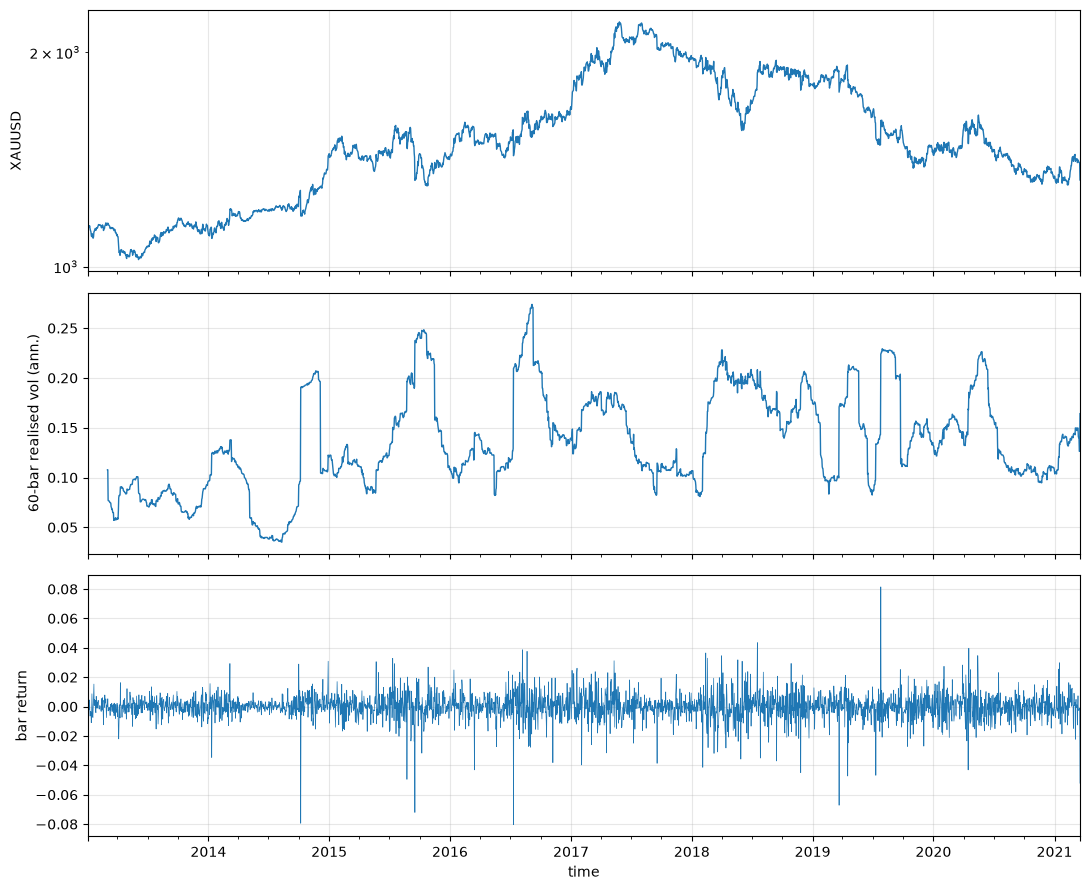

In [3]:
rets = prices["close"].pct_change().dropna()

fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
prices["close"].plot(ax=ax[0], lw=1); ax[0].set_ylabel("XAUUSD"); ax[0].set_yscale("log")
(rets.rolling(60).std() * np.sqrt(ANN)).plot(ax=ax[1], lw=1)
ax[1].set_ylabel("60-bar realised vol (ann.)")
rets.plot(ax=ax[2], lw=0.5); ax[2].set_ylabel("bar return")
plt.tight_layout()

print(f"annualised vol      {rets.std() * np.sqrt(ANN):.1%}")
print(f"vol of vol (60b)    {(rets.rolling(60).std() * np.sqrt(ANN)).std():.1%}")
print(f"excess kurtosis     {rets.kurtosis():.1f}   <- fat tails; a 5-sigma day is not rare")
print(f"worst bar           {rets.min():.2%}")
print(f"autocorr lag 1      {rets.autocorr(1):+.3f}")

Two facts drive everything downstream:

- **Volatility is not constant.** It moves by a factor of 3+ between regimes. A fixed
  lot size means your risk per trade in a crisis is triple what it is in a drift, and
  your drawdowns end up being a story about *when* vol spiked, not about your signal.
  That is what `vol_target` in the backtester fixes.
- **Tails are fat.** Kurtosis well above 0 means normal-distribution intuitions about
  "a 3-sigma loss is a 1-in-700 event" are wrong. Size for the tail, not the average.

## 3. The baseline you have to beat

In [4]:
bt = Backtest(prices, costs=RETAIL_TYPICAL, vol_target=0.10, vol_lookback=60)
bh = bt.buy_and_hold()

print("Buy and hold, vol-targeted to 10%:")
bh.stats().to_frame().T

Buy and hold, vol-targeted to 10%:


,CAGR,AnnVol,Sharpe,Sortino,MaxDD,Calmar,TimeUnderWater_bars,TotalReturn,Bars,Exposure,AnnTurnover,n_trades,hit_rate,avg_trade,profit_factor,CostDrag
buy & hold,0.0001,0.1115,0.0567,0.0668,-0.3782,0.0002,"1,325.0000",0.0008,"2,999.0000",0.9800,3.2717,1.0000,1.0000,0.0008,inf,0.0069


Gold has a long-run drift and a real diversification role. **Any strategy that does not
beat this risk-adjusted is not worth trading**, because holding gold requires no
research, no execution, and no ongoing cost.

## 4. Candidate signals, in-sample

In [5]:
candidates = {
    "MA crossover 20/100":   st.ma_crossover(prices, fast=20, slow=100),
    "Donchian 55/20":        st.donchian_breakout(prices, entry=55, exit=20),
    "TS momentum 120":       st.ts_momentum(prices, lookback=120),
    "Z-reversion 20 / 2.0":  st.zscore_reversion(prices, n=20, entry=2.0),
    "Trend-filtered rev.":   st.trend_filtered_reversion(prices, trend=200, n=20),
}

results = {name: bt.run(sig, label=name) for name, sig in candidates.items()}
table = pd.DataFrame({name: r.stats() for name, r in results.items()}).T
table = pd.concat([table, bh.stats().to_frame("buy & hold").T])
table[["CAGR", "AnnVol", "Sharpe", "MaxDD", "Calmar", "n_trades", "hit_rate",
       "profit_factor", "Exposure", "AnnTurnover", "CostDrag"]]

,CAGR,AnnVol,Sharpe,MaxDD,Calmar,n_trades,hit_rate,profit_factor,Exposure,AnnTurnover,CostDrag
MA crossover 20/100,0.0084,0.1115,0.1311,-0.2569,0.0327,36.0000,0.2778,1.2239,0.9800,7.8177,0.0165
Donchian 55/20,0.0106,0.0937,0.1599,-0.1717,0.0618,30.0000,0.4667,1.3263,0.6419,5.9227,0.0125
TS momentum 120,-0.0197,0.1100,-0.1254,-0.3448,-0.0571,94.0000,0.2660,0.8137,0.9600,15.2330,0.0311
Z-reversion 20 / 2.0,-0.0020,0.0759,0.0118,-0.2568,-0.0077,110.0000,0.6545,1.0258,0.4258,17.3543,0.0369
Trend-filtered rev.,-0.0042,0.0328,-0.1115,-0.1633,-0.0256,47.0000,0.5745,0.8778,0.1180,6.8136,0.0143
buy & hold,0.0001,0.1115,0.0567,-0.3782,0.0002,1.0000,1.0000,inf,0.9800,3.2717,0.0069


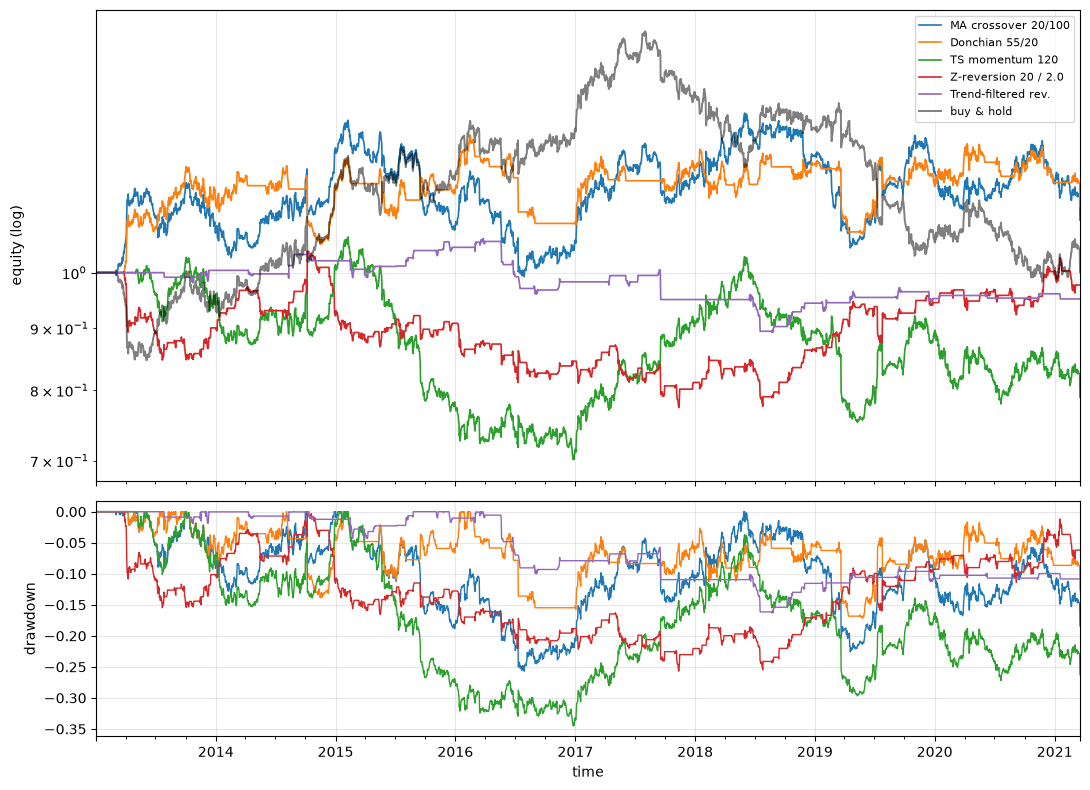

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
for name, r in results.items():
    r.equity.plot(ax=ax[0], lw=1.2, label=name)
bh.equity.plot(ax=ax[0], lw=1.4, color="k", alpha=0.5, label="buy & hold")
ax[0].set_yscale("log"); ax[0].set_ylabel("equity (log)"); ax[0].legend(fontsize=8)

for name, r in results.items():
    r.drawdown.plot(ax=ax[1], lw=1)
ax[1].set_ylabel("drawdown")
plt.tight_layout()

> **Read the drawdown panel, not the equity panel.** The equity curve tells you what
> the strategy returned. The drawdown panel tells you what you would have had to sit
> through to collect it - and whether you actually would have.

### 4b. If you have intraday bars: gold is a session instrument

Gold's volatility is not spread evenly through the day. The Asian session is quiet,
London brings the first real volume, and the US session carries the macro releases that
move it. A signal that ignores this is averaging over regimes that behave differently.

This cell is skipped on daily data.

In [7]:
step = prices.index.to_series().diff().median()
if step < pd.Timedelta("1D"):
    sess = st.session_breakout(prices, range_start="00:00", range_end="07:00", close_at="20:00")
    res = bt.run(sess, label="Asian-range breakout")
    display(res.stats().to_frame().T)

    hour = prices.index.tz_convert("UTC").hour
    by_hour = prices["close"].pct_change().abs().groupby(hour).mean()
    fig, ax = plt.subplots(figsize=(10, 3))
    by_hour.plot(kind="bar", ax=ax)
    ax.set_xlabel("UTC hour"); ax.set_ylabel("mean |return|")
    ax.set_title("Intraday volatility profile")
    plt.tight_layout()
else:
    print(f"Daily bars ({step}) - skipping the session section. "
          "Re-run with M15/H1 data to use it.")

Daily bars (1 days 00:00:00) - skipping the session section. Re-run with M15/H1 data to use it.


## 5. Cost sensitivity: the first thing that kills an idea

In [8]:
scenarios = {"tight 0.20": RETAIL_TIGHT, "typical 0.30": RETAIL_TYPICAL,
             "wide 0.50": RETAIL_WIDE, "stress 2x typical": RETAIL_TYPICAL.with_stress(2.0)}

rows = {}
for cname, cm in scenarios.items():
    b = Backtest(prices, costs=cm, vol_target=0.10)
    rows[cname] = {name: sharpe(b.run(sig).returns, b.ann) for name, sig in candidates.items()}
cost_table = pd.DataFrame(rows)
cost_table["decay"] = cost_table["tight 0.20"] - cost_table["stress 2x typical"]
cost_table.sort_values("decay")

,tight 0.20,typical 0.30,wide 0.50,stress 2x typical,decay
Donchian 55/20,0.1644,0.1599,0.1487,0.1487,0.0157
MA crossover 20/100,0.1360,0.1311,0.1187,0.1187,0.0174
TS momentum 120,-0.1159,-0.1254,-0.1491,-0.1491,0.0332
Trend-filtered rev.,-0.0968,-0.1115,-0.1481,-0.1481,0.0513
Z-reversion 20 / 2.0,0.0281,0.0118,-0.0291,-0.0291,0.0572


A strategy whose Sharpe collapses between "tight" and "stress" is not trading an edge,
it is trading your broker's spread estimate. Your real fills during news (NFP, CPI, FOMC)
look like the stress column, not the tight one - and a breakout strategy takes most of
its trades precisely when spreads widen.

**Rule of thumb:** if it does not survive 2x your assumed costs, it will not survive live.

## 6. Parameter surface: look for a plateau, not a peak

best in-sample Sharpe: 0.38 at fast=30, slow=50


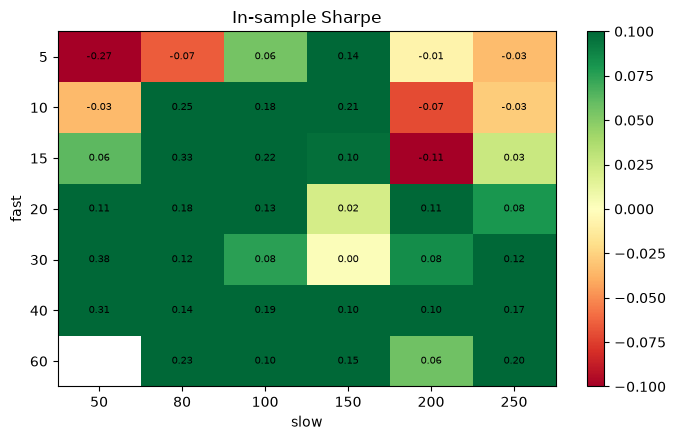

In [9]:
SPACE = {"fast": [5, 10, 15, 20, 30, 40, 60], "slow": [50, 80, 100, 150, 200, 250]}
sweep = val.param_sweep(prices, st.ma_crossover, SPACE, costs=RETAIL_TYPICAL, vol_target=0.10)
surface = val.sweep_surface(sweep, x="slow", y="fast", metric="Sharpe")

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(surface.values, cmap="RdYlGn", aspect="auto",
               vmin=-abs(surface.values).max(), vmax=abs(surface.values).max())
ax.set_xticks(range(len(surface.columns)), surface.columns)
ax.set_yticks(range(len(surface.index)), surface.index)
ax.set_xlabel("slow"); ax.set_ylabel("fast"); ax.set_title("In-sample Sharpe")
ax.grid(False)
for i in range(surface.shape[0]):
    for j in range(surface.shape[1]):
        v = surface.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im); plt.tight_layout()

print(f"best in-sample Sharpe: {sweep['Sharpe'].max():.2f} at "
      f"fast={sweep.iloc[0]['fast']:.0f}, slow={sweep.iloc[0]['slow']:.0f}")

**How to read this.** A single bright cell surrounded by dull ones is an artefact: it
means one specific pair of numbers happened to line up with this particular price
history. You would not have picked it in advance, and it will not repeat.

A broad connected region that is green is a real (if weak) property of the series. Pick
the **middle of the plateau**, not the maximum - the middle is the choice that is robust
to the parameter drifting slightly wrong, which it will.

## 7. What that maximum is worth, given how hard you searched

In [10]:
n_trials = len(sweep)
hurdle = val.multiple_testing_hurdle(n_trials, len(prices), ANN)
best = sweep["Sharpe"].max()

print(f"parameter combinations tested : {n_trials}")
print(f"best in-sample Sharpe         : {best:.3f}")
print(f"expected best from pure noise : {hurdle:.3f}")
print(f"verdict                       : "
      f"{'clears the search hurdle' if best > hurdle else 'INDISTINGUISHABLE FROM NOISE'}")

parameter combinations tested : 41
best in-sample Sharpe         : 0.378
expected best from pure noise : 0.637
verdict                       : INDISTINGUISHABLE FROM NOISE


This is the correction people skip. Testing 42 parameter pairs on one price series and
reporting the winner is not one experiment, it is 42 - and the best of 42 coin-flip
strategies still has a respectable-looking Sharpe. If your best result does not clear
the noise hurdle, you have measured the size of your search, not an edge.

Note the hurdle grows with the number of trials and *shrinks* with sample length. More
data is the only thing that lets you search harder honestly.

## 8. Walk-forward: the only number that is an estimate of the future

In [11]:
oos, report = val.walk_forward(prices, st.ma_crossover, SPACE, n_splits=5,
                               costs=RETAIL_TYPICAL, vol_target=0.10)
print(f"stitched out-of-sample Sharpe : {sharpe(oos, ANN):.3f}")
print(f"in-sample sweep maximum       : {best:.3f}")
print(f"degradation                   : {best - sharpe(oos, ANN):.3f}")
report

stitched out-of-sample Sharpe : -0.080
in-sample sweep maximum       : 0.378
degradation                   : 0.458


,fold,train_end,test_start,test_end,fast,slow,IS_Sharpe,OOS_Sharpe,OOS_Return
0,0,2015-06-19 00:00:00+00:00,2015-06-20 00:00:00+00:00,2016-08-12 00:00:00+00:00,60,200,0.7910,-1.1981,-0.2172
1,1,2016-08-12 00:00:00+00:00,2016-08-13 00:00:00+00:00,2017-10-06 00:00:00+00:00,40,250,0.3576,0.8581,0.1453
2,2,2017-10-06 00:00:00+00:00,2017-10-07 00:00:00+00:00,2018-11-30 00:00:00+00:00,15,80,0.5788,0.7231,0.1298
3,3,2018-11-30 00:00:00+00:00,2018-12-01 00:00:00+00:00,2020-01-24 00:00:00+00:00,15,80,0.6068,-0.0756,-0.0267
4,4,2020-01-24 00:00:00+00:00,2020-01-25 00:00:00+00:00,2021-03-19 00:00:00+00:00,30,50,0.5264,-0.5673,-0.1061


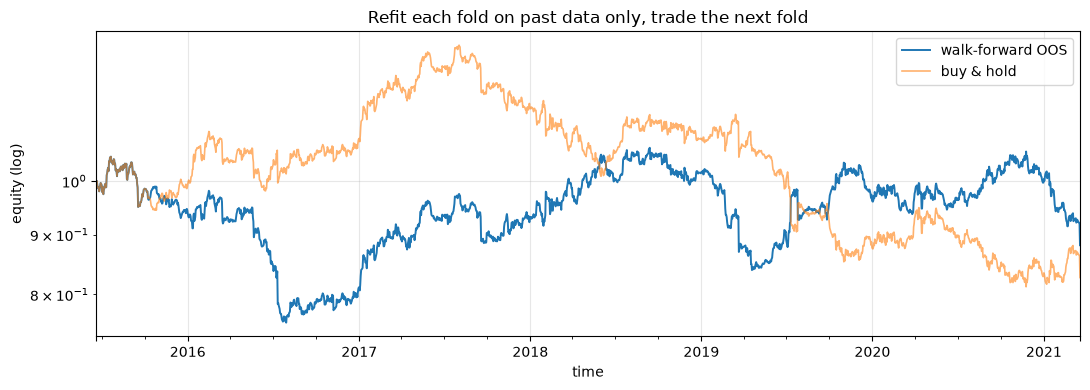

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
(1 + oos).cumprod().plot(ax=ax, lw=1.4, label="walk-forward OOS")
(1 + bh.returns.loc[oos.index[0]:]).cumprod().plot(ax=ax, lw=1.2, alpha=0.6, label="buy & hold")
ax.set_yscale("log"); ax.set_ylabel("equity (log)"); ax.legend()
ax.set_title("Refit each fold on past data only, trade the next fold")
plt.tight_layout()

Every fold picks its parameters using only data that preceded it, then trades the next
window untouched. The stitched curve is what the strategy would have actually returned
if you had run it, re-tuning as you went.

**Expect degradation.** In-sample Sharpe minus out-of-sample Sharpe is the size of your
overfitting. If OOS is near zero or negative while in-sample looked strong, the sweep
found history, not structure. Consistency across folds matters more than the average:
one great fold carrying four bad ones is a regime, not an edge.

## 9. Permutation test: could this have happened by chance?

observed Sharpe 0.160 | null mean -0.041 | null p95 0.376 | p-value 0.219


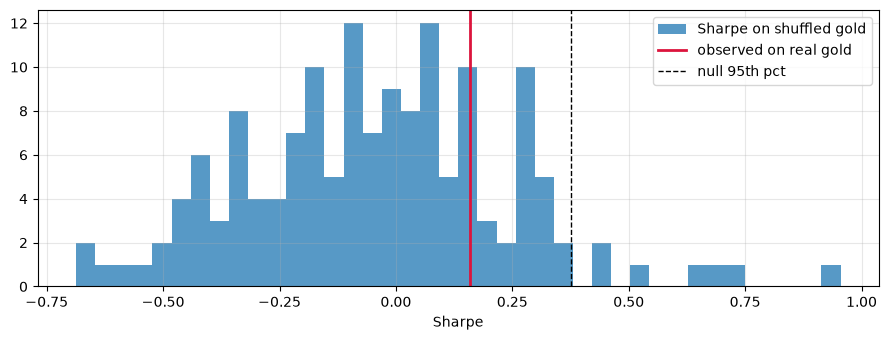

In [13]:
pt = val.permutation_test(prices, st.donchian_breakout, {"entry": 55, "exit": 20},
                          n_permutations=150, costs=RETAIL_TYPICAL, vol_target=0.10)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(pt["null"], bins=40, alpha=0.75, label="Sharpe on shuffled gold")
ax.axvline(pt["observed_sharpe"], color="crimson", lw=2, label="observed on real gold")
ax.axvline(pt["null_p95"], color="k", ls="--", lw=1, label="null 95th pct")
ax.legend(); ax.set_xlabel("Sharpe"); plt.tight_layout()

print(f"observed Sharpe {pt['observed_sharpe']:.3f} | null mean {pt['null_mean']:.3f} "
      f"| null p95 {pt['null_p95']:.3f} | p-value {pt['p_value']:.3f}")

Each permutation reshuffles gold's bar-to-bar returns, keeping the volatility and the
bar geometry but destroying the time ordering the strategy claims to exploit. If the
strategy scores as well on scrambled gold as on real gold, it is responding to the
*shape* of price data in general, not to anything about gold's actual behaviour.

Treat p > 0.05 as "no evidence of an edge". And note this tests one fixed parameter set:
run it on the parameters you chose *before* seeing the sweep, or you are smuggling the
search back in.

## 10. How uncertain is that Sharpe, really?

point estimate 0.16   90% CI [-0.27, 0.67]
P(true Sharpe <= 0) ~ 24.9%


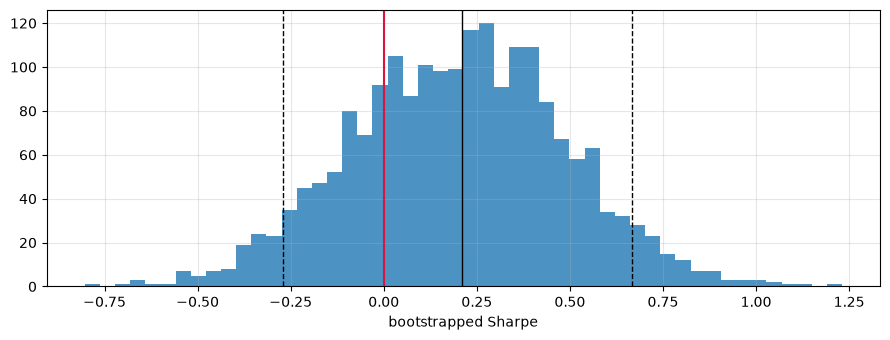

In [14]:
chosen = results["Donchian 55/20"]
boot = val.block_bootstrap_sharpe(chosen.returns, ANN, block=20, n=2000)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(boot, bins=50, alpha=0.8)
for q, style in [(0.05, "--"), (0.5, "-"), (0.95, "--")]:
    ax.axvline(boot.quantile(q), color="k", ls=style, lw=1)
ax.axvline(0, color="crimson", lw=1.5)
ax.set_xlabel("bootstrapped Sharpe"); plt.tight_layout()

lo, hi = boot.quantile(0.05), boot.quantile(0.95)
print(f"point estimate {sharpe(chosen.returns, ANN):.2f}   90% CI [{lo:.2f}, {hi:.2f}]")
print(f"P(true Sharpe <= 0) ~ {(boot <= 0).mean():.1%}")

A Sharpe of 0.6 measured over 8 years typically carries a confidence interval that
comfortably contains 0.0. That is not a flaw in the method - it is how much information
8 years of one asset actually contains. The practical consequence: **you cannot tell a
Sharpe 0.6 strategy from a Sharpe 0.0 strategy quickly**, so any plan that depends on
knowing within a few months whether your system works is not going to work.

## 11. Sizing, and what an edge actually implies for an account

**Which numbers you feed this decides everything it tells you.** The in-sample fit and
the walk-forward result describe the same strategy; only one of them is a forecast.
Run both, side by side, so the difference is impossible to ignore.

In [15]:
START, TARGET, HORIZON = 10_000, 1_000_000, int(10 * ANN)   # ten years of bars

sources = {
    "in-sample fit (NOT a forecast)": chosen.returns,
    "walk-forward OOS (the honest one)": oos,
}

rows = {}
mc = {}
for name, series in sources.items():
    mu, sd = series.mean(), series.std(ddof=1)
    mc[name] = risk.target_paths(START, TARGET, mu, sd, n_steps=HORIZON,
                                 n_paths=20_000, ruin_frac=0.9)
    rows[name] = {
        "per-bar mean": mu,
        "per-bar std": sd,
        "ann. Sharpe": sharpe(series, ANN),
        "P(reach $1M)": mc[name]["p_reach_target"],
        "P(lose 90% first)": mc[name]["p_ruin_first"],
        "median final": mc[name]["median_final"],
        "5th pct": mc[name]["p5_final"],
        "95th pct": mc[name]["p95_final"],
    }

print(f"${START:,} -> ${TARGET:,} over {HORIZON:,} bars (~10 years)\n")
pd.DataFrame(rows).T

$10,000 -> $1,000,000 over 2,520 bars (~10 years)



,per-bar mean,per-bar std,ann. Sharpe,P(reach $1M),P(lose 90% first),median final,5th pct,95th pct
in-sample fit (NOT a forecast),0.0001,0.0059,0.1599,0.0000,0.0000,"11,110.7951","6,845.0227","18,196.3309"
walk-forward OOS (the honest one),-0.0000,0.0070,-0.0805,0.0000,0.0000,"8,588.6524","4,831.5209","15,432.7305"


The first row is the fantasy: it takes the parameters that fit this history best and
assumes they keep working. The second row is the estimate you would actually be
betting on. Section 7 already told you the in-sample maximum did not clear the search
hurdle, and section 9 could not distinguish it from shuffled gold - so the first row is
a measurement of the search, projected forward with compound interest.

If a strategy's honest row says the target is unlikely, that is the answer. Turning it
into a likely one requires a real edge, more capital, or more time - not a bigger
position, which mostly moves probability into the ruin column.

In [16]:
paths = mc["walk-forward OOS (the honest one)"]

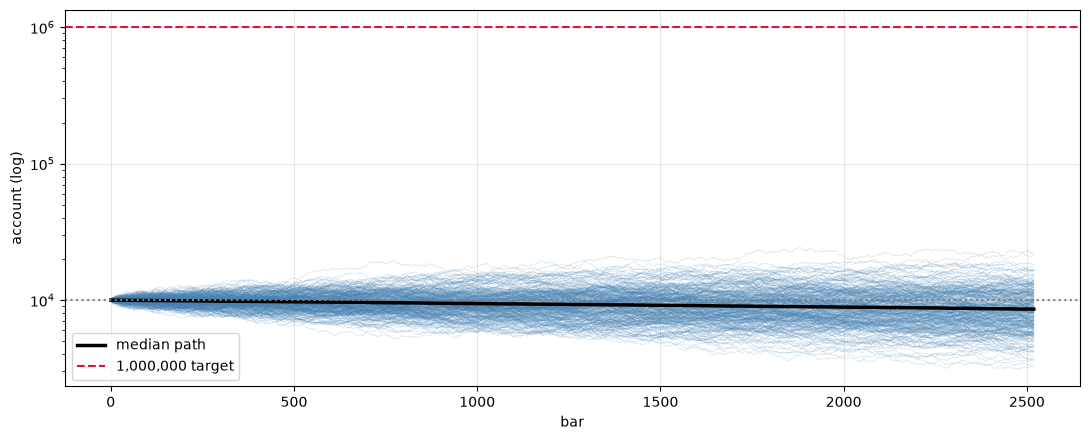

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sample = paths["curves"][np.random.default_rng(0).choice(len(paths["curves"]), 300, replace=False)]
ax.plot(sample.T, lw=0.4, alpha=0.25, color="steelblue")
ax.plot(np.median(paths["curves"], axis=0), lw=2.5, color="k", label="median path")
ax.axhline(TARGET, color="crimson", ls="--", label=f"{TARGET:,.0f} target")
ax.axhline(START, color="grey", ls=":")
ax.set_yscale("log"); ax.set_xlabel("bar"); ax.set_ylabel("account (log)")
ax.legend(); plt.tight_layout()

**The gap between the mean and the median is the whole story.** The mean outcome is
inflated by a handful of paths that compounded spectacularly; the median is what a
typical run of this strategy actually does. Marketing quotes the mean. You live the median.

The fan above is the walk-forward row. Note how wide it is: ten years of the *same*
strategy, differing only in the order the returns arrive, spans orders of magnitude.
That spread is irreducible - it is not a modelling artefact you can tune away.

Note what raises `P(reach target)`: bigger bets. And what bigger bets do to
`P(lose 90% first)`. That trade-off is not optimisable away - it is the arithmetic of
compounding under uncertainty. Kelly gives the growth-maximising bet, and it is
famously too large to trade because it assumes you know your edge exactly:

In [18]:
k = risk.kelly_fraction(oos.mean(), oos.var(ddof=1))
print(f"full Kelly (per bar)      {k:.2f} of account   <- from walk-forward moments")
print(f"half Kelly                {k / 2:.2f}")
print(f"quarter Kelly (practical) {k / 4:.2f}")
print("A negative or huge Kelly is the estimator telling you the edge is not "
      "measurable here.\n")

for f in [0.005, 0.01, 0.02, 0.05, 0.10]:
    ror = risk.risk_of_ruin(win_rate=0.40, payoff=2.0, risk_frac=f, ruin_frac=0.5)
    print(f"risking {f:.1%} per trade  ->  P(50% drawdown in 1000 trades) = {ror:6.1%}")

full Kelly (per bar)      -0.72 of account   <- from walk-forward moments
half Kelly                -0.36
quarter Kelly (practical) -0.18
A negative or huge Kelly is the estimator telling you the edge is not measurable here.



risking 0.5% per trade  ->  P(50% drawdown in 1000 trades) =   0.0%


risking 1.0% per trade  ->  P(50% drawdown in 1000 trades) =   0.0%


risking 2.0% per trade  ->  P(50% drawdown in 1000 trades) =   0.2%


risking 5.0% per trade  ->  P(50% drawdown in 1000 trades) =  12.1%


risking 10.0% per trade  ->  P(50% drawdown in 1000 trades) =  47.0%


That last table uses a *genuinely profitable* system (40% win rate, 2:1 payoff, positive
expectancy). Risk too much per trade and it still destroys the account. Most retail
accounts do not die from bad signals; they die from correct signals sized wrong.

Convert a chosen risk fraction into lots with `risk.units_from_risk` - XAUUSD standard
lot is 100 oz, so a \$1 move is \$100 per lot:

In [19]:
from xau.strategies import atr
current_atr = atr(prices, 14).iloc[-1]
stop_distance = 2.0 * current_atr

for equity in [1_000, 10_000, 50_000]:
    lots = risk.units_from_risk(equity, risk_frac=0.01, stop_distance_usd=stop_distance)
    print(f"equity ${equity:>7,}  risking 1%  stop {stop_distance:6.2f} USD/oz  "
          f"-> {lots:.3f} lots  (${lots * 100 * stop_distance:,.0f} at risk)")

equity $  1,000  risking 1%  stop  45.72 USD/oz  -> 0.002 lots  ($10 at risk)
equity $ 10,000  risking 1%  stop  45.72 USD/oz  -> 0.022 lots  ($100 at risk)
equity $ 50,000  risking 1%  stop  45.72 USD/oz  -> 0.109 lots  ($500 at risk)


## 12. Plugging in your own idea

,CAGR,AnnVol,Sharpe,Sortino,MaxDD,Calmar,TimeUnderWater_bars,TotalReturn,Bars,Exposure,AnnTurnover,n_trades,hit_rate,avg_trade,profit_factor,CostDrag
my_signal,-0.0421,0.0864,-0.4542,-0.4120,-0.5004,-0.0842,"2,724.0000",-0.4007,"2,999.0000",0.5228,35.8442,235.0000,0.2128,-0.0019,0.6933,0.0762


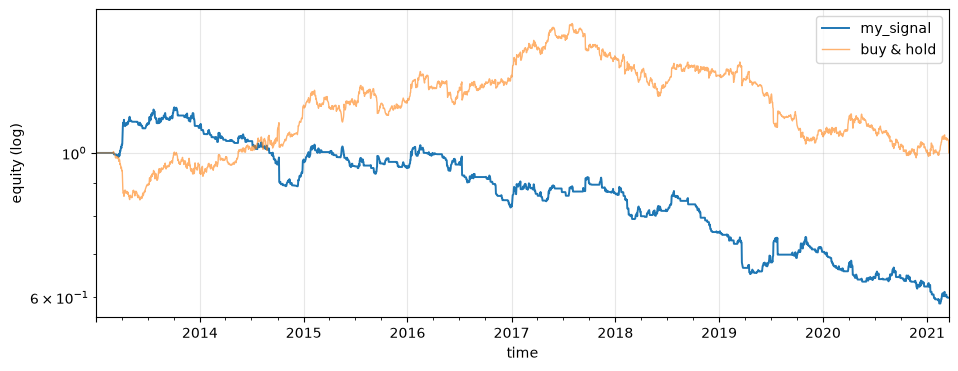

In [20]:
def my_signal(prices: pd.DataFrame, lookback: int = 50, threshold: float = 1.0) -> pd.Series:
    '''Replace this with your idea.

    Contract:
      - return a Series in [-1, 1] aligned to prices.index
      - every value at bar t may use ONLY data up to and including bar t's close
      - if you use .shift(-n), .rolling(...).mean() centred, or anything that
        reads forward, you are backtesting a time machine
    '''
    close = prices["close"]
    z = (close - close.rolling(lookback).mean()) / close.rolling(lookback).std(ddof=1)
    return np.sign(z).where(z.abs() > threshold, 0.0).fillna(0.0)


mine = bt.run(my_signal(prices), label="my_signal")
mine.plot(benchmark=bh.returns)
mine.stats().to_frame().T

Then run it through the same gauntlet - and in this order, because each step is cheaper
than the next and most ideas die early:

```python
# 5  costs
{n: sharpe(Backtest(prices, costs=c, vol_target=0.10).run(my_signal(prices)).returns, ANN)
   for n, c in scenarios.items()}

# 6-7  search surface and the noise hurdle
sw = val.param_sweep(prices, my_signal, {"lookback": [...], "threshold": [...]})
val.multiple_testing_hurdle(len(sw), len(prices), ANN)

# 8  walk-forward - the number that counts
val.walk_forward(prices, my_signal, {"lookback": [...], "threshold": [...]}, n_splits=5)

# 9  is it distinguishable from shuffled gold?
val.permutation_test(prices, my_signal, {"lookback": 50}, n_permutations=500)
```

## 13. Checklist before any of this touches money

- [ ] Out-of-sample walk-forward Sharpe is positive and reasonably consistent across folds
- [ ] Best in-sample result clears the multiple-testing hurdle from section 7
- [ ] Permutation p-value below 0.05 on parameters chosen *before* the sweep
- [ ] Sharpe survives 2x assumed costs
- [ ] Bootstrap 90% CI on Sharpe excludes zero (or you accept you cannot yet tell)
- [ ] Max drawdown is one you would actually hold through - be honest, this is the one people get wrong
- [ ] Sizing set from risk-of-ruin, at most quarter-Kelly
- [ ] Forward-tested on a demo account for long enough to see the drawdown profile, with
      *your broker's* real spreads and slippage, not this notebook's assumptions

**On the million.** Take the honest walk-forward numbers into section 11 and read
`P(reach target)` and `P(lose 90% first)` together. If the answer disappoints, that is
information, not a reason to raise leverage - raising leverage moves probability mass
into the ruin bucket faster than into the target bucket. The variables that actually
move the outcome are, in order: **how much you deposit**, **how long you compound**, and
**whether the edge is real**. Leverage is the one that feels like it helps and is the
one that ends accounts.